**Group 5:**
1. Lucia Francescoli
2. Frank Novoa
3. Maxime Engels
4. Tiziano Gallo




**Problem Description:**

The Japanese higher education system is highly competitive and internationally recognized. Students who wish to study in Japan face complex decisions, considering factors such as internationalization of the university, research impact, and graduate employability.


**Research Question:**

which universities and regions in Japan offer the best opportunities for international students, considering internationalization, research impact, and employability, and to detect geographic gaps or inequalities that could hinder the attraction of global talent.

**Stakeholders:**

International students

**About Datasets**

1. **Japan Top 50 Universities Dataset:** This dataset tracks the academic and professional performance of the top 52 universities in Japan.

      **Variables:**
      * *`University_Name:`* The recognized international English name.
      * *`National_Rank:`* Comprehensive 2026 rank based on academic reputation, employer reputation, and faculty/student ratio.
      * *`Founded_Year:`* The year of original founding (or the effective date of a major structural merger).
      * *`Institution_Type`*: National (Government-funded), Public (Prefectural/Municipal), or Private.
      * *`Region_code:`* The geographic prefecture code
      * *`Research_Impact_Score:`* A weighted metric (0-100) analyzing citations per faculty and research grants.
      * *`Intl_Student_Ratio:`* Percentage of non-Japanese degree-seeking students.
      * *`Employment_Rate:`* The percentage of graduates entering full-time employment or higher-level graduate studies.

      **Link:** https://www.kaggle.com/datasets/nudratabbas/japan-top-50-universities-dataset

2. **Japan Region Dataset:** This dataset provides basic demographic and geographic information for all 47 prefectures of Japan in 2024.

      **Variables:**
      * *`Region_code:`* The geographic prefecture code
      * *`Region:`* The name of the prefecture/region in Japan
      * *`Total_Population:`* Total population (Both sexes) in 2024

2. **Japan Expenditure Dataset:** This dataset provides basic expenditures information for all 47 prefectures of Japan in 2007.

      **Variables:**
      * *`Region_code:`* The geographic prefecture code
      * *`Region:`* The name of the prefecture/region in Japan
      * *`Living_Expenditure:`* Average living expenditures in Yen in 2007
      * *`Housing_Expenditure:`* Average housing expenditure in Yen in 2007
      * *`Education_Expenditure:`* Average education expenditure in 2007

      **Link:** https://www.e-stat.go.jp/en/regional-statistics/ssdsview/prefectures

In [1]:
!pip install pyspark


In [2]:
from pyspark.sql import SparkSession

# Create Spark session
spark = SparkSession.builder \
    .appName("Japan_Unis") \
    .getOrCreate()

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [4]:
from pyspark.sql.types import *
from pyspark.sql.functions import *

# **Importing CSV files**

**Option 1: Running the code in Google Colab**

Select the following datasets:

1. japan_universities_2026.csv
2. region_japan_2024.csv
3. expenditure_region.csv



In [5]:
from google.colab import files
uploaded = files.upload()

df_ranking = spark.read.csv("/content/japan_universities_2026.csv", header=True, inferSchema=True)

df_region = spark.read.csv("/content/region_japan_2024.csv", header=True, inferSchema=True)

df_expenditure = spark.read.csv("/content/expenditure_region.csv", header=True, inferSchema=True)

df_region_analysis = df_ranking.join(df_region, "Region_Code")\
    .groupBy("Region", "Total_Population")\
    .agg(
        count("*").alias("Num_Universities"),
        avg("Intl_Student_Ratio").alias("Avg_Intl_Ratio")
    )\
    .withColumn("Universities_per_Million",
                round(col("Num_Universities") / (col("Total_Population")/1000000), 2))


Saving expenditure_region.csv to expenditure_region.csv
Saving japan_universities_2026.csv to japan_universities_2026.csv
Saving region_japan_2024.csv to region_japan_2024.csv


**Option 2: Running the code locally**

In [6]:

df_ranking = spark.read.csv("japan_universities_2026.csv", header=True, inferSchema=True)

df_region = spark.read.csv("region_japan_2024.csv", header=True, inferSchema=True)

df_expenditure = spark.read.csv("expenditure_region.csv", header=True, inferSchema=True)

df_region_analysis = df_ranking.join(df_region, "Region_Code")\
    .groupBy("Region", "Total_Population")\
    .agg(
        count("*").alias("Num_Universities"),
        avg("Intl_Student_Ratio").alias("Avg_Intl_Ratio")
    )\
    .withColumn("Universities_per_Million",
                round(col("Num_Universities") / (col("Total_Population")/1000000), 2))


In [7]:
df_region_analysis.show()

+---------+----------------+----------------+------------------+------------------------+
|   Region|Total_Population|Num_Universities|    Avg_Intl_Ratio|Universities_per_Million|
+---------+----------------+----------------+------------------+------------------------+
|    Aichi|         7460000|               2|              8.45|                    0.27|
|    Chiba|         6251000|               1|               7.8|                    0.16|
|    Akita|          897000|               1|              26.5|                    1.11|
|    Tokyo|        14178000|              14|11.385714285714286|                    0.99|
| Hokkaido|         5043000|               1|              10.5|                     0.2|
|   Miyagi|         2248000|               1|              11.8|                    0.44|
|   Nagano|         1987000|               1|               5.1|                     0.5|
|Tokushima|          685000|               1|               4.2|                    1.46|
| Ishikawa

In [8]:
df_ranking.printSchema()

root
 |-- University_Name: string (nullable = true)
 |-- National_Rank: integer (nullable = true)
 |-- Founded_Year: integer (nullable = true)
 |-- Institution_Type: string (nullable = true)
 |-- Region_Code: integer (nullable = true)
 |-- Research_Impact_Score: double (nullable = true)
 |-- Intl_Student_Ratio: double (nullable = true)
 |-- Employment_Rate: double (nullable = true)



In [9]:
df_ranking.show()

+--------------------+-------------+------------+----------------+-----------+---------------------+------------------+---------------+
|     University_Name|National_Rank|Founded_Year|Institution_Type|Region_Code|Research_Impact_Score|Intl_Student_Ratio|Employment_Rate|
+--------------------+-------------+------------+----------------+-----------+---------------------+------------------+---------------+
| University of Tokyo|            1|        1877|        National|      13000|                 98.5|              14.2|           94.5|
|    Kyoto University|            2|        1897|        National|      26000|                 97.2|              12.5|           93.8|
|   Tohoku University|            3|        1907|        National|       4000|                 94.8|              11.8|           95.2|
|Institute of Scie...|            4|        2024|        National|      13000|                 95.1|              12.8|           97.5|
|    Osaka University|            5|        1931

In [10]:
df_region.printSchema()

root
 |-- Region_Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Total_Population: integer (nullable = true)



In [11]:
df_region.show()

+-----------+---------+----------------+
|Region_Code|   Region|Total_Population|
+-----------+---------+----------------+
|          0|All Japan|       123802000|
|       1000| Hokkaido|         5043000|
|       2000|   Aomori|         1165000|
|       3000|    Iwate|         1145000|
|       4000|   Miyagi|         2248000|
|       5000|    Akita|          897000|
|       6000| Yamagata|         1011000|
|       7000|Fukushima|         1743000|
|       8000|  Ibaraki|         2806000|
|       9000|  Tochigi|         1885000|
|      10000|    Gunma|         1890000|
|      11000|  Saitama|         7332000|
|      12000|    Chiba|         6251000|
|      13000|    Tokyo|        14178000|
|      14000| Kanagawa|         9225000|
|      15000|  Niigata|         2099000|
|      16000|   Toyama|          997000|
|      17000| Ishikawa|         1098000|
|      18000|    Fukui|          739000|
|      19000|Yamanashi|          791000|
+-----------+---------+----------------+
only showing top

In [12]:
df_region_stats = df_ranking.join(
    df_region,
    on="Region_Code"
).groupBy("Region").agg(
    avg("Intl_Student_Ratio").alias("Avg_Intl"),
    avg("Employment_Rate").alias("Avg_Employment"),
    avg("Research_Impact_Score").alias("Avg_Research")
)

In [13]:
df_region_stats.show()

+---------+------------------+-----------------+-----------------+
|   Region|          Avg_Intl|   Avg_Employment|     Avg_Research|
+---------+------------------+-----------------+-----------------+
|    Aichi|              8.45|            95.65|            71.25|
|    Kyoto|11.799999999999999|94.89999999999999|73.16666666666667|
| Hokkaido|              10.5|             93.0|             87.5|
|  Fukuoka| 8.149999999999999|            95.15|             70.2|
|     Oita|              48.5|             94.2|             48.8|
|   Toyama|               4.5|             85.1|             66.1|
|    Ehime|               3.9|             84.2|             64.1|
|    Tokyo|11.385714285714284|95.75000000000001|68.95714285714287|
|     Nara|              22.5|             96.5|             52.8|
|  Okayama|               8.2|             89.8|             75.1|
|    Akita|              26.5|             95.0|             50.8|
|  Ibaraki|              13.8|             91.5|             8

**1. Find the top 3 universities with the highest proportion of international students.**

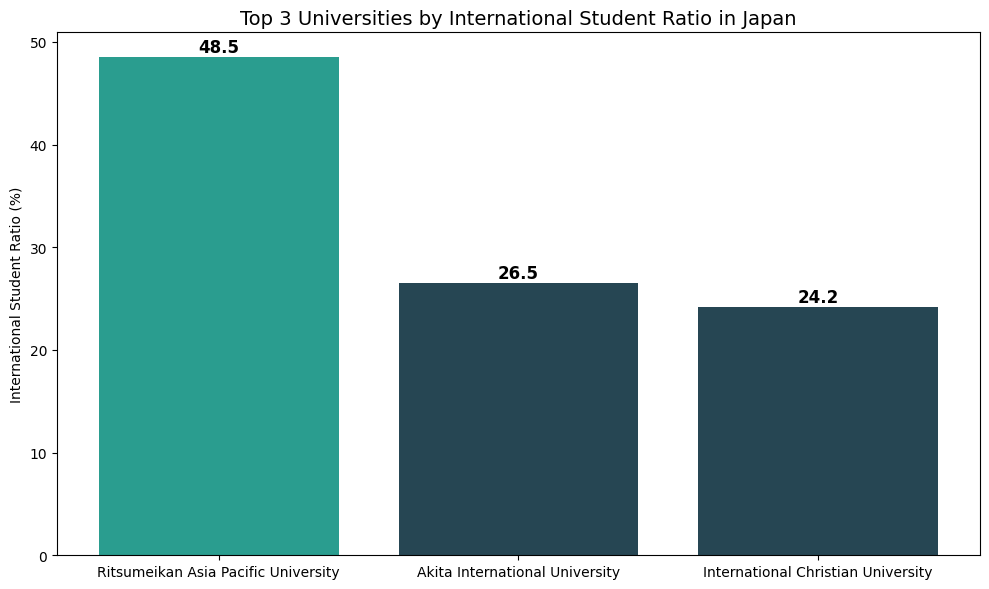

In [14]:
df_ranking_top3 = df_ranking.orderBy(df_ranking.Intl_Student_Ratio.desc()).limit(3)
ranking_top3 = df_ranking_top3.toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2a9d8f', '#264653', '#264653']
bars = ax.bar(ranking_top3['University_Name'], ranking_top3['Intl_Student_Ratio'], color=colors)
for bar, val in zip(bars, ranking_top3['Intl_Student_Ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Top 3 Universities by International Student Ratio in Japan', fontsize=14)
ax.set_ylabel('International Student Ratio (%)')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


**Conclusion:** Ritsumeikan Asia Pacific University has the highest proportion of international students. Followed by Akita International University and International Chistrian University.

**2. Find the region with the highest number of universities.**

In [15]:
df_joined = df_ranking.join(
    df_region,
    df_ranking.Region_Code == df_region.Region_Code
).select(
    "University_Name",
    df_region.Region,
)

region_counts = df_joined.groupBy("Region").agg(count("*")).withColumnRenamed("count(1)", "Num_Universities")
region_counts.show()

+---------+----------------+
|   Region|Num_Universities|
+---------+----------------+
|    Aichi|               2|
|    Kyoto|               3|
| Hokkaido|               1|
|  Fukuoka|               2|
|     Oita|               1|
|   Toyama|               1|
|    Ehime|               1|
|    Tokyo|              14|
|     Nara|               1|
|  Okayama|               1|
|    Akita|               1|
|  Ibaraki|               1|
|Yamaguchi|               1|
|   Nagano|               1|
|Fukushima|               1|
|      Mie|               1|
|    Chiba|               1|
|   Miyagi|               1|
| Shizuoka|               1|
|Tokushima|               1|
+---------+----------------+
only showing top 20 rows


In [16]:
max_num_univ_reg = region_counts.groupBy().max("Num_Universities").take(1)[0][0]

print(max_num_univ_reg)

df_max_num_univ_reg=region_counts.where(
    region_counts.Num_Universities == max_num_univ_reg
)
df_max_num_univ_reg.show()

14
+------+----------------+
|Region|Num_Universities|
+------+----------------+
| Tokyo|              14|
+------+----------------+



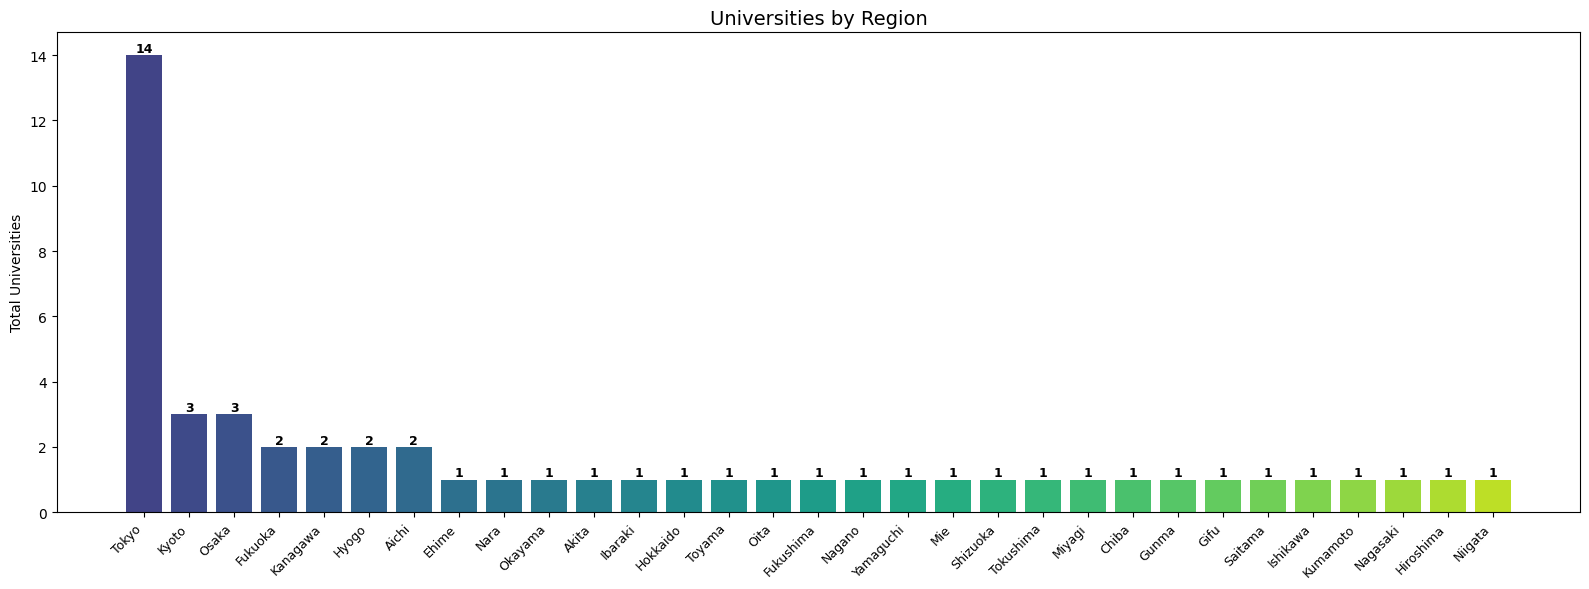

In [17]:
region_count = region_counts.toPandas().sort_values('Num_Universities', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(region_count)))
bars = ax.bar(region_count['Region'], region_count['Num_Universities'], color=colors)
for bar, val in zip(bars, region_count['Num_Universities']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Universities by Region', fontsize=14)
ax.set_ylabel('Total Universities')
ax.set_facecolor('white')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


**Conclusion:** A high number of universities means more program variety, courses, and study environments, making Tokyo attractive for students from abroad.

**3. For each type of institution, calculate the average proportion of international students and count the number of universities**

In [18]:
df_type = df_ranking.groupBy("Institution_Type").agg(
    count("*"),
    avg("Intl_Student_Ratio").alias("Avg_Intl_Student_Ratio"),
).orderBy("Avg_Intl_Student_Ratio", ascending=False)\
.withColumn("Avg_Intl_Student_Ratio", round("Avg_Intl_Student_Ratio", 2))\
.withColumnRenamed("count(1)", "Num_Universities")

df_type.show()

+----------------+----------------+----------------------+
|Institution_Type|Num_Universities|Avg_Intl_Student_Ratio|
+----------------+----------------+----------------------+
|          Public|               4|                 15.27|
|         Private|              16|                 12.41|
|        National|              32|                  8.58|
+----------------+----------------+----------------------+



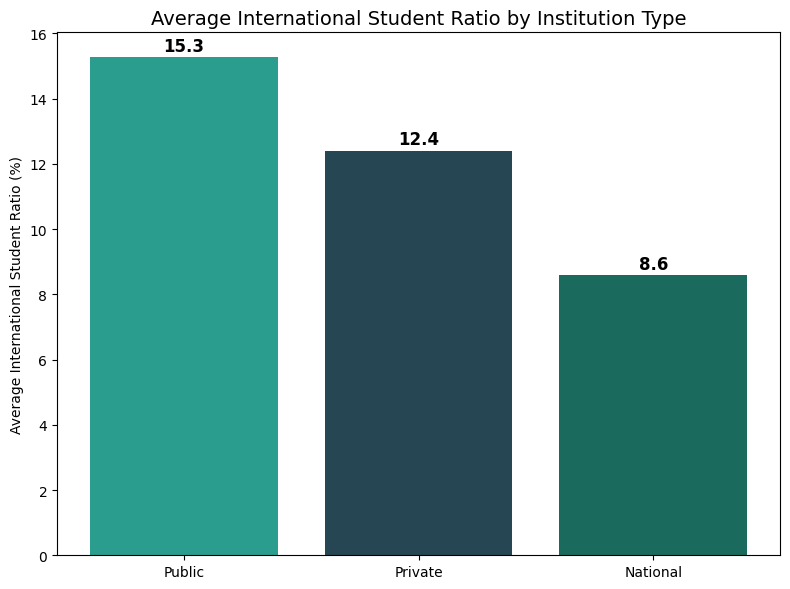

In [19]:
type_pd = df_type.toPandas().sort_values('Avg_Intl_Student_Ratio', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2a9d8f', '#264653', '#1a6b5e']
bars = ax.bar(type_pd['Institution_Type'], type_pd['Avg_Intl_Student_Ratio'], color=colors)
for bar, val in zip(bars, type_pd['Avg_Intl_Student_Ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Average International Student Ratio by Institution Type', fontsize=14)
ax.set_ylabel('Average International Student Ratio (%)')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()


**Conclusion:** Public universities, although few in number, have a higher average proportion of international students compared to private and national universities. This suggests that, relatively, public universities are more open or attractive to international students.

**4. Find the top 10 universities in Japan that provide the best graduate employability for students.**

In [20]:
top10_employment = df_ranking.select(
    'University_Name',
    'Institution_Type',
    'Employment_Rate'
).orderBy(
    col("Employment_Rate").desc()
).limit(10)
top10_employment.show()

+--------------------+----------------+---------------+
|     University_Name|Institution_Type|Employment_Rate|
+--------------------+----------------+---------------+
|Shibaura Institut...|         Private|           98.2|
|Hitotsubashi Univ...|        National|           98.0|
|Nagoya Institute ...|        National|           97.8|
|Institute of Scie...|        National|           97.5|
|Tokyo University ...|         Private|           97.5|
|Kyushu Institute ...|        National|           97.5|
|     Keio University|         Private|           97.2|
|   Waseda University|         Private|           96.8|
|Nara Institute of...|        National|           96.5|
|    Meiji University|         Private|           96.2|
+--------------------+----------------+---------------+



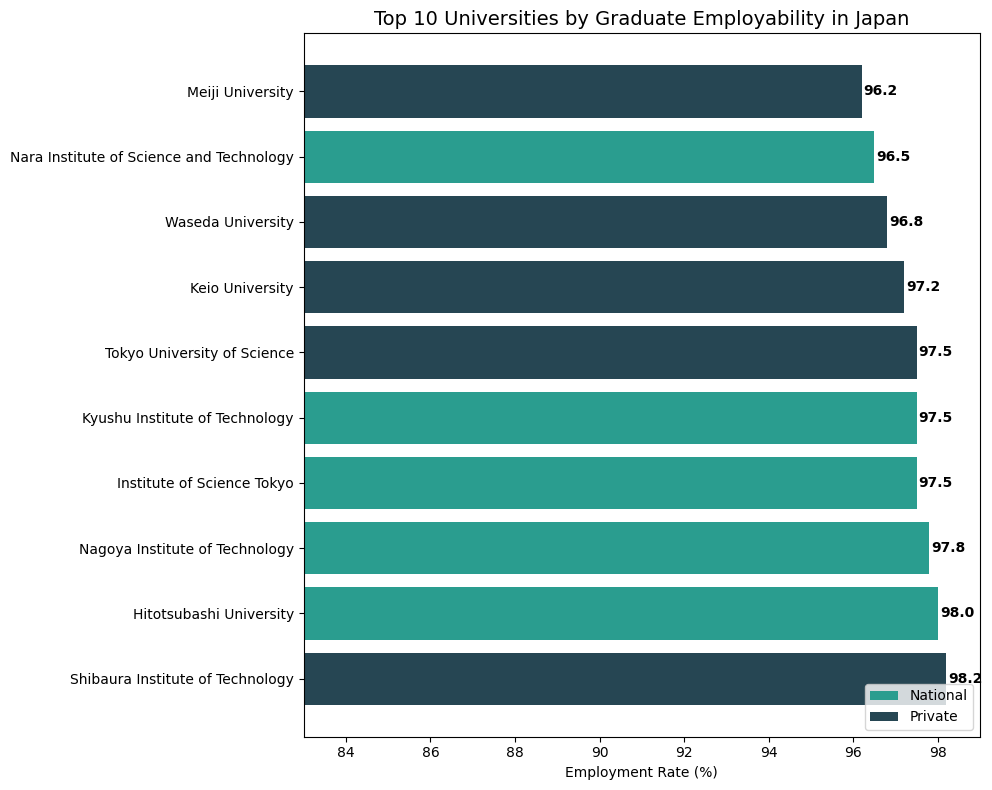

In [21]:
top_employ = top10_employment.toPandas().sort_values(by=["Employment_Rate", "Institution_Type"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2a9d8f' if t == 'National' else '#264653' for t in top_employ['Institution_Type']]
bars = ax.barh(top_employ['University_Name'], top_employ['Employment_Rate'], color=colors)
for bar, val in zip(bars, top_employ['Employment_Rate']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Top 10 Universities by Graduate Employability in Japan', fontsize=14)
ax.set_xlabel('Employment Rate (%)')
ax.set_xlim(83, 99)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2a9d8f', label='National'), Patch(facecolor='#264653', label='Private')]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()


**Conclusion:** Private and national universities in Japan tend to have strong industry connections and higher graduate employability rates. In contrast, public universities do not appear among the top-ranked institutions for employability.

**5. Find the top 5 universities in Japan that offer the highest overall opportunity for international students, considering research impact, employability, and internationalization.**

In [22]:
def opportunity_score(research, employment, intl_ratio):
    """
    Calculates a simple opportunity score for international students
    by combining research impact, employability, and internationalization.
    For this we considered research, employment and international ratio as equaly important for students.
    """
    return (research + employment + intl_ratio) / 3

In [23]:
opportunity_udf = udf(opportunity_score, DoubleType())

df_scores = df_ranking.withColumn(
    "Opportunity_Score",
    opportunity_udf(
        df_ranking.Research_Impact_Score,
        df_ranking.Employment_Rate,
        df_ranking.Intl_Student_Ratio
    )
)

df_scores_university = df_scores.orderBy(col("Opportunity_Score").desc()).select(
    "University_Name", "Opportunity_Score"
).limit(5)

df_scores_university.show()

+--------------------+-----------------+
|     University_Name|Opportunity_Score|
+--------------------+-----------------+
| University of Tokyo|69.06666666666666|
|Institute of Scie...|68.46666666666667|
|    Kyoto University|67.83333333333333|
|   Tohoku University|67.26666666666667|
|    Osaka University|65.66666666666667|
+--------------------+-----------------+



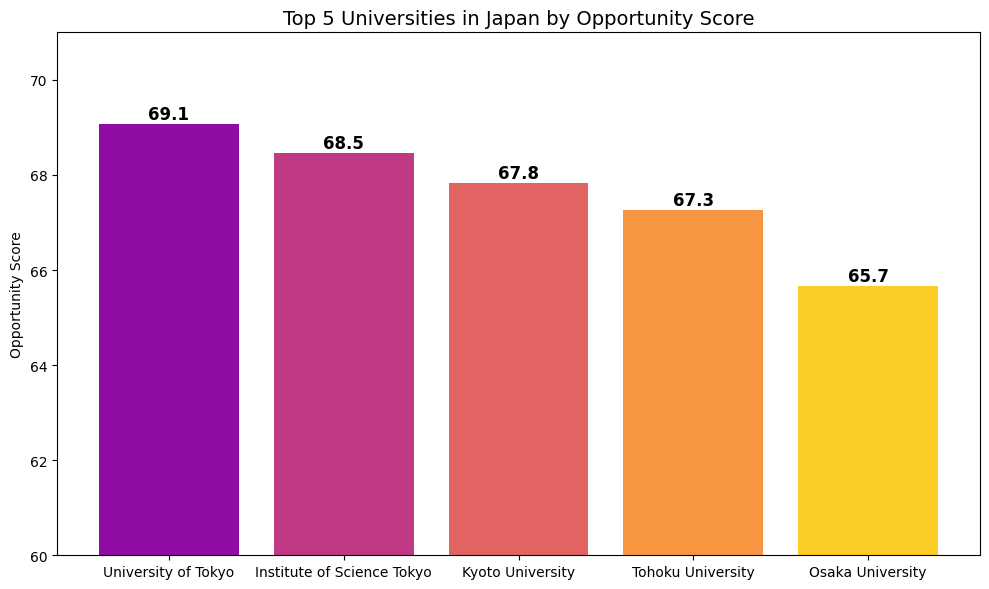

In [24]:
top_score_pd = df_scores_university.select("University_Name", "Opportunity_Score").toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_score_pd)))
bars = ax.bar(top_score_pd['University_Name'], top_score_pd['Opportunity_Score'], color=colors)
for bar, val in zip(bars, top_score_pd['Opportunity_Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Universities in Japan by Opportunity Score', fontsize=14)
ax.set_ylabel('Opportunity Score')
ax.set_ylim(60, 71)
ax.set_facecolor('white')
plt.tight_layout()
plt.show()


**Conclusion:** The University of Tokyo has the highest Opportunity Score among Japanese universities. This indicates that it offers the best overall opportunities for international students seeking quality education, career prospects, and an international environment.

**6. Find the regions with highest inequality.**



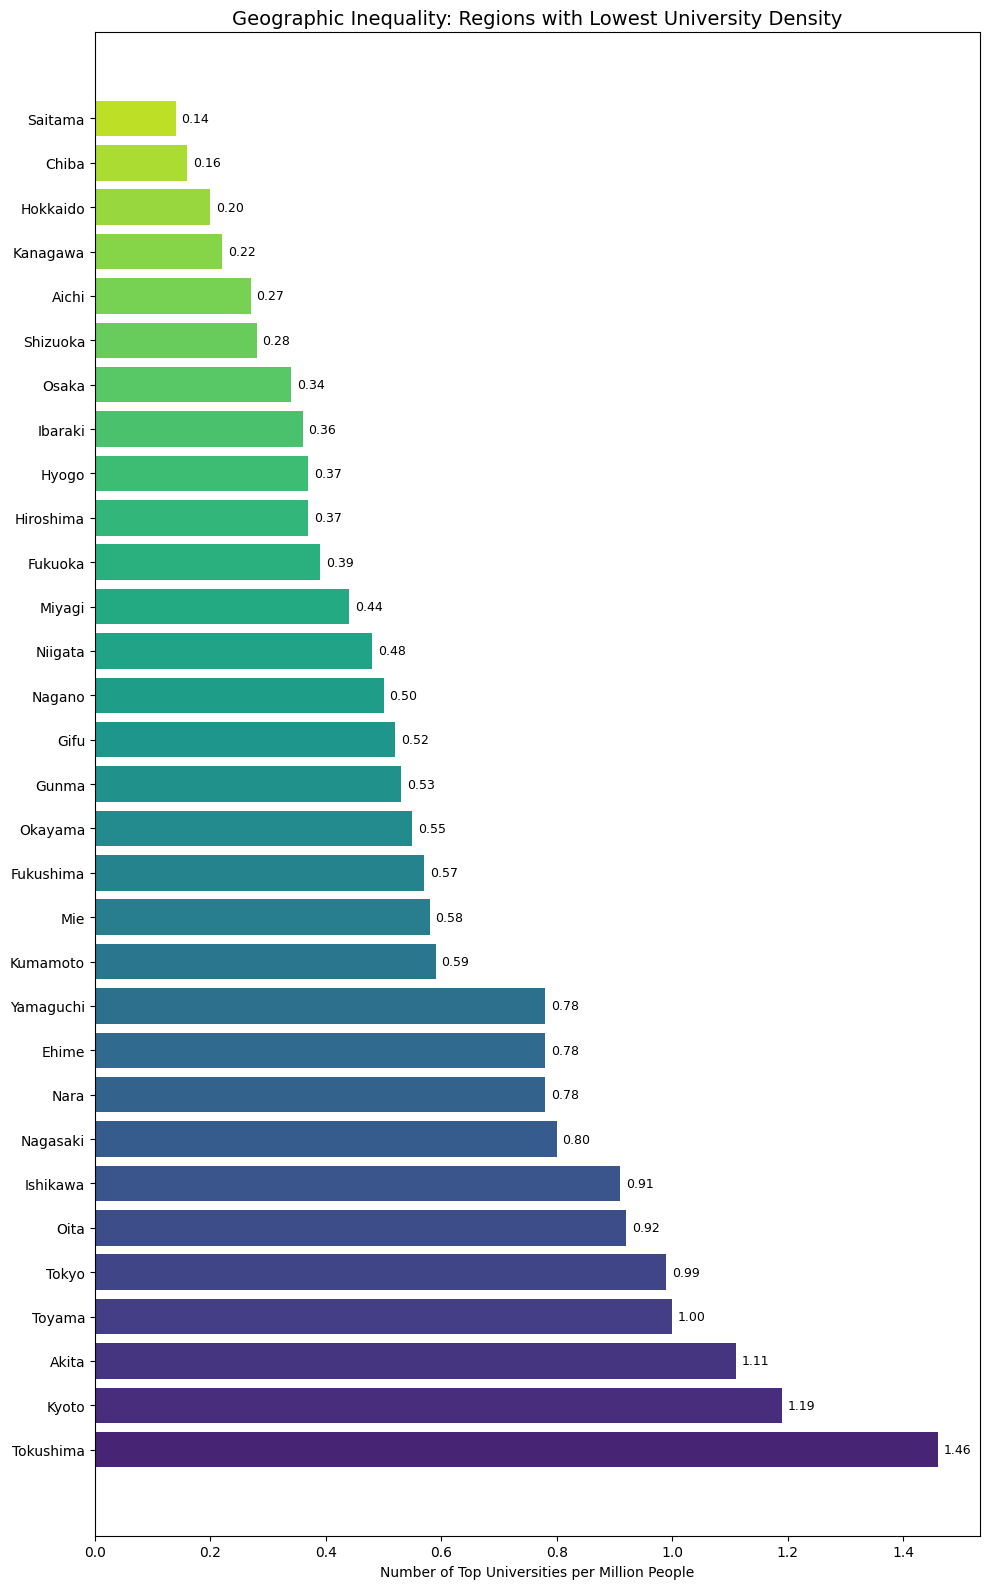

In [25]:
gap_pd = df_region_analysis.orderBy(col("Universities_per_Million").desc()).toPandas()

fig, ax = plt.subplots(figsize=(10, 16))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gap_pd)))
bars = ax.barh(gap_pd['Region'], gap_pd['Universities_per_Million'], color=colors)
for bar, val in zip(bars, gap_pd['Universities_per_Million']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
ax.set_title('Geographic Inequality: Regions with Lowest University Density', fontsize=14)
ax.set_xlabel('Number of Top Universities per Million People')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()


**Conclusion:** Saitama is the region with the most significant geographic inequality, having the lowest university density relative to its population.

**7. Find if there is a relation between a high international student body and employability in Japanese universities**



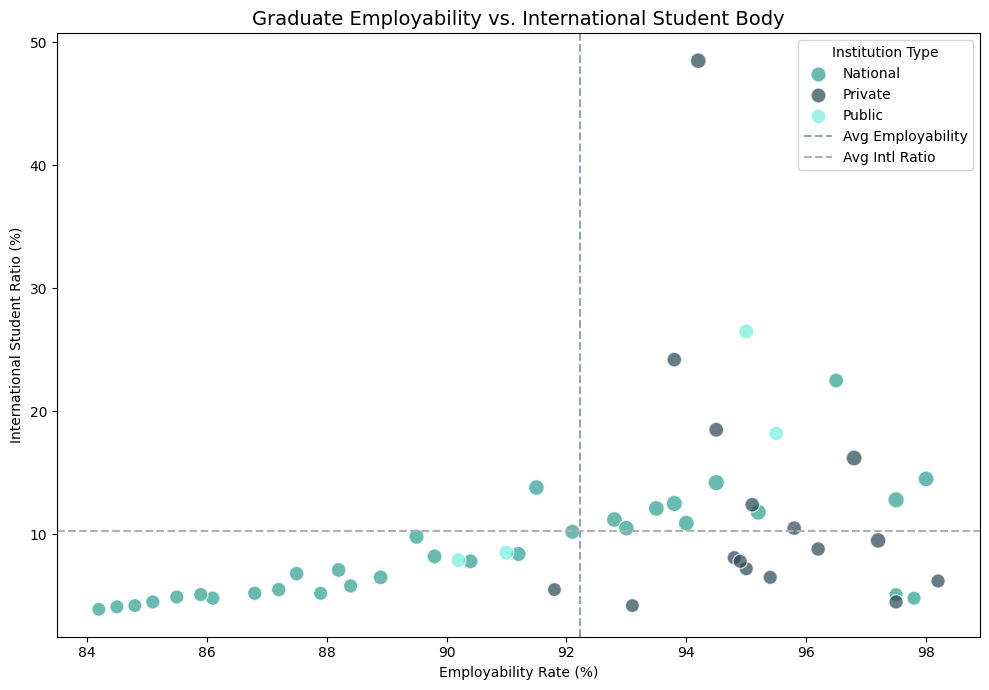

In [26]:
df_all_scores = df_ranking.withColumn(
    "Opportunity_Score",
    opportunity_udf(
        col("Research_Impact_Score"),
        col("Employment_Rate"),
        col("Intl_Student_Ratio")
    )
)

df_final = df_all_scores.select(
    "University_Name", "Employment_Rate", "Intl_Student_Ratio", "Opportunity_Score", "Institution_Type"
)
df_plot = df_final.toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
color_map = {'National': '#2a9d8f', 'Private': '#264653', 'Public': '#72efdd'}
for inst_type, group in df_plot.groupby('Institution_Type'):
    ax.scatter(group['Employment_Rate'], group['Intl_Student_Ratio'],
               s=group['Opportunity_Score'] * 2,
               color=color_map.get(inst_type, 'grey'),
               label=inst_type, alpha=0.7, edgecolors='white')
avg_emp = df_plot['Employment_Rate'].mean()
avg_intl = df_plot['Intl_Student_Ratio'].mean()
ax.axvline(x=avg_emp, linestyle='--', color='#94a3b8', label='Avg Employability')
ax.axhline(y=avg_intl, linestyle='--', color='#b0b0b0', label='Avg Intl Ratio')
ax.set_title('Graduate Employability vs. International Student Body', fontsize=14)
ax.set_xlabel('Employability Rate (%)')
ax.set_ylabel('International Student Ratio (%)')
ax.legend(title='Institution Type')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()


**Conclusion:** Universities with fewer international students usually have lower employment rates, and national universities seem to be a top choice because they have both many international students and great job prospects.

**8. Find the top 10 Universities sorted by lowest living expenditures**


In [27]:
df_ranking.printSchema()

root
 |-- University_Name: string (nullable = true)
 |-- National_Rank: integer (nullable = true)
 |-- Founded_Year: integer (nullable = true)
 |-- Institution_Type: string (nullable = true)
 |-- Region_Code: integer (nullable = true)
 |-- Research_Impact_Score: double (nullable = true)
 |-- Intl_Student_Ratio: double (nullable = true)
 |-- Employment_Rate: double (nullable = true)



In [28]:
df_expenditure.printSchema()

root
 |-- Region_Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Living_Expenditure_Yen: string (nullable = true)
 |-- Housing_Expenditure_Yen: string (nullable = true)
 |-- Education_Expenditure_Yen: string (nullable = true)



In [29]:
#Join the two datasets
df_joined = df_ranking.join(df_expenditure, on='Region_Code', how='inner')

df_joined.printSchema()
df_joined.show(5)

root
 |-- Region_Code: integer (nullable = true)
 |-- University_Name: string (nullable = true)
 |-- National_Rank: integer (nullable = true)
 |-- Founded_Year: integer (nullable = true)
 |-- Institution_Type: string (nullable = true)
 |-- Research_Impact_Score: double (nullable = true)
 |-- Intl_Student_Ratio: double (nullable = true)
 |-- Employment_Rate: double (nullable = true)
 |-- Region: string (nullable = true)
 |-- Living_Expenditure_Yen: string (nullable = true)
 |-- Housing_Expenditure_Yen: string (nullable = true)
 |-- Education_Expenditure_Yen: string (nullable = true)

+-----------+--------------------+-------------+------------+----------------+---------------------+------------------+---------------+------+----------------------+-----------------------+-------------------------+
|Region_Code|     University_Name|National_Rank|Founded_Year|Institution_Type|Research_Impact_Score|Intl_Student_Ratio|Employment_Rate|Region|Living_Expenditure_Yen|Housing_Expenditure_Yen|Educa

In [30]:
df_cleaned = df_joined.withColumn("Living_Expenditure_Yen_Cleaned",
                                    regexp_replace(col("Living_Expenditure_Yen"), ",", "").cast(IntegerType()))

In [31]:
top_universities_by_expenditure = (df_cleaned.orderBy(col("National_Rank")).limit(10)
                                   .orderBy(col("Living_Expenditure_Yen_Cleaned"))
                                   .select("Region", "University_Name", "National_Rank", "Living_Expenditure_Yen_Cleaned"))

top_universities_by_expenditure.show(truncate=False)

+--------+--------------------------+-------------+------------------------------+
|Region  |University_Name           |National_Rank|Living_Expenditure_Yen_Cleaned|
+--------+--------------------------+-------------+------------------------------+
|Osaka   |Osaka University          |5            |280799                        |
|Kyoto   |Kyoto University          |2            |287824                        |
|Hokkaido|Hokkaido University       |8            |288574                        |
|Aichi   |Nagoya University         |6            |296585                        |
|Miyagi  |Tohoku University         |3            |305091                        |
|Fukuoka |Kyushu University         |7            |307732                        |
|Tokyo   |University of Tokyo       |1            |326281                        |
|Tokyo   |Institute of Science Tokyo|4            |326281                        |
|Tokyo   |Keio University           |10           |326281                        |
|Iba

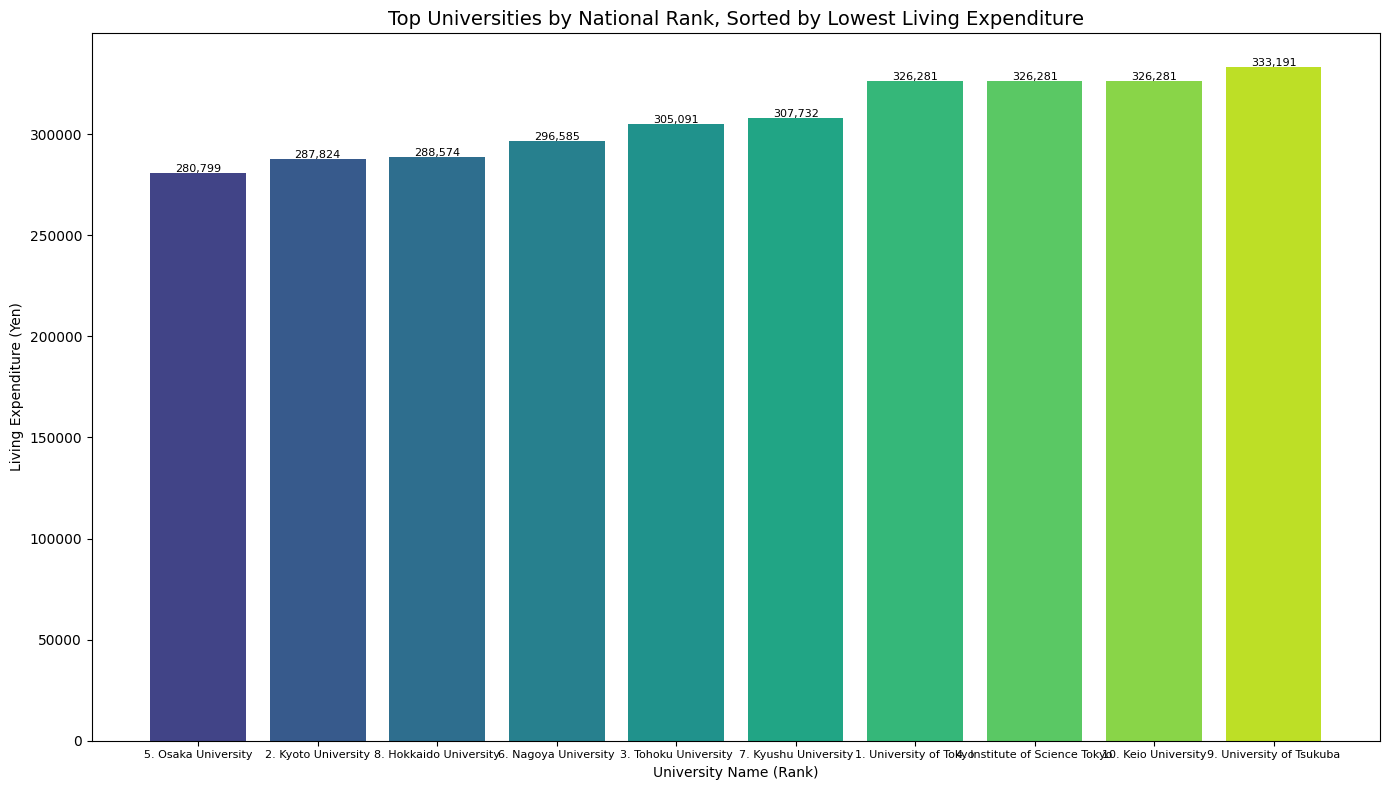

In [37]:
df_plot = top_universities_by_expenditure.toPandas()
df_plot['University_Name_Rank'] = df_plot['National_Rank'].astype(str) + '. ' + df_plot['University_Name']
df_plot = df_plot.sort_values('Living_Expenditure_Yen_Cleaned')

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df_plot)))
bars = ax.bar(df_plot['University_Name_Rank'], df_plot['Living_Expenditure_Yen_Cleaned'], color=colors)
for bar, val in zip(bars, df_plot['Living_Expenditure_Yen_Cleaned']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{val:,.0f}', ha='center', fontsize=8, rotation=0)
ax.set_title('Top Universities by National Rank, Sorted by Lowest Living Expenditure', fontsize=14)
ax.set_xlabel('University Name (Rank)')
ax.set_ylabel('Living Expenditure (Yen)')
ax.set_facecolor('white')
plt.xticks(rotation=0, ha='center', fontsize=8) # Changed rotation to 0 and alignment to center
plt.tight_layout()
plt.show()

**Conclusion:** Top-ranked universities outside Tokyo are cheaper to live in than Tokyo-based ones. High academic quality does not require high living expenditure.


**9. Compare the top 10 universities with the highest employment rate and their living expenditure**




In [33]:
top_universities_employment_by_expenditure = (df_cleaned.orderBy(col("Employment_Rate").desc()).limit(10)
                                                    .select("Region", "University_Name", "National_Rank", "Employment_Rate", "Living_Expenditure_Yen_Cleaned"))

top_universities_employment_by_expenditure.show(truncate=False)

+-------+----------------------------------------+-------------+---------------+------------------------------+
|Region |University_Name                         |National_Rank|Employment_Rate|Living_Expenditure_Yen_Cleaned|
+-------+----------------------------------------+-------------+---------------+------------------------------+
|Tokyo  |Shibaura Institute of Technology        |45           |98.2           |326281                        |
|Tokyo  |Hitotsubashi University                 |12           |98.0           |326281                        |
|Aichi  |Nagoya Institute of Technology          |47           |97.8           |296585                        |
|Tokyo  |Institute of Science Tokyo              |4            |97.5           |326281                        |
|Tokyo  |Tokyo University of Science             |38           |97.5           |326281                        |
|Fukuoka|Kyushu Institute of Technology          |48           |97.5           |307732                  

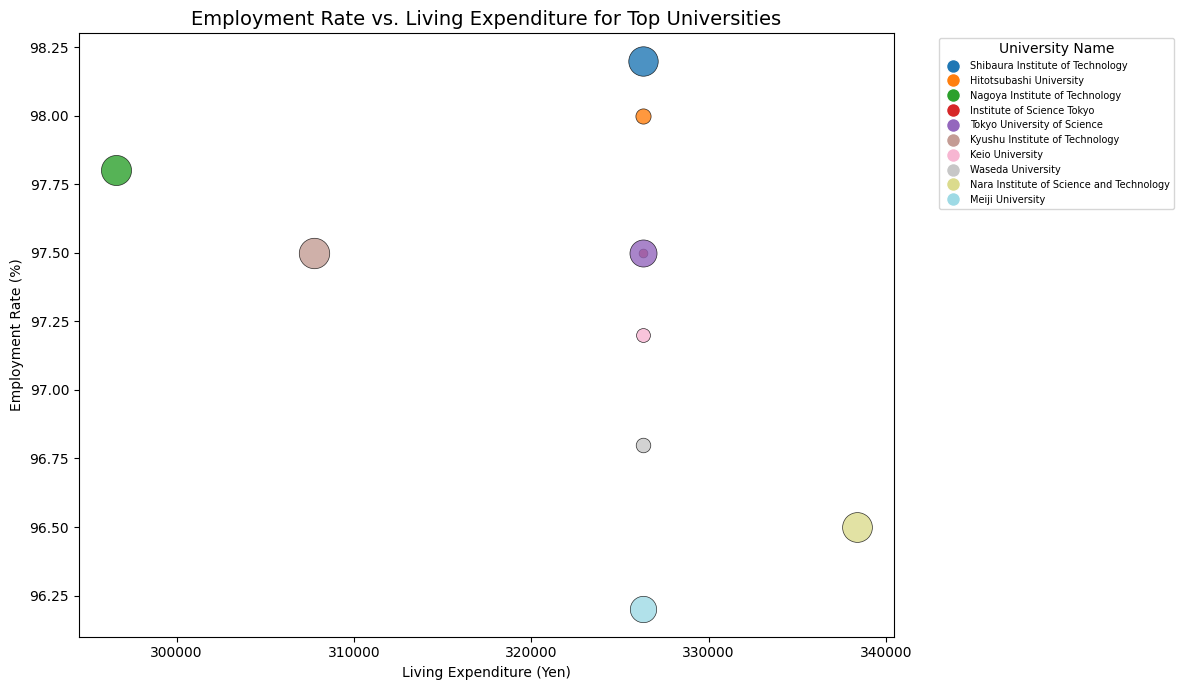

In [36]:
from matplotlib.lines import Line2D

df_plot = top_universities_employment_by_expenditure.toPandas()

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(df_plot)))

# Create scatter plot with size variation
for i, row in df_plot.iterrows():
    ax.scatter(row['Living_Expenditure_Yen_Cleaned'], row['Employment_Rate'],
               s=row['National_Rank'] * 10, # Re-add the size based on National_Rank
               color=colors[i % len(colors)],
               alpha=0.8, edgecolors='black', linewidths=0.5)

# Create custom legend handles for uniform size in legend
legend_handles = []
legend_labels = []
for i, row in df_plot.iterrows():
    legend_handles.append(Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=colors[i % len(colors)],
                                 markersize=10)) # Fixed marker size for legend
    legend_labels.append(row['University_Name'])

ax.set_title('Employment Rate vs. Living Expenditure for Top Universities', fontsize=14)
ax.set_xlabel('Living Expenditure (Yen)')
ax.set_ylabel('Employment Rate (%)')
ax.legend(handles=legend_handles, labels=legend_labels, title='University Name',
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

**Conclusion:** Employment rates remain high across universities, regardless of living expenditure, and higher living expenditure does not guarantee better employment outcomes.